In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# main.jl が吐く data の絶対パスに合わせる
DATA_ROOT = Path("/home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data")
DATA_ROOT


PosixPath('/home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data')

In [4]:
import re
from pathlib import Path

def find_csv(seed: int, end_alpha: float, tau: int, h: float, J: float, alpha_inc: str, tol: float = 1e-12) -> Path:
    seed_dir = DATA_ROOT / f"seed{seed}"
    if not seed_dir.exists():
        raise FileNotFoundError(f"seed directory not found: {seed_dir}")

    dir_prefix = f"tau{tau}_h{h}_J{J}_α_inc{alpha_inc}"
    target_dir = seed_dir / dir_prefix
    if not target_dir.exists():
        target_dir = seed_dir  # 念のため

    # ファイル名から alpha を抽出: ..._alpha0.8_... の 0.8 部分
    pat = re.compile(r"_alpha([0-9]+(?:\.[0-9]+)?)_")

    cand = []
    for p in target_dir.rglob("*.csv"):
        m = pat.search(p.name)
        if not m:
            continue
        a = float(m.group(1))
        if abs(a - end_alpha) <= tol:
            cand.append(p)

    if not cand:
        # デバッグ用：見つからない場合、存在する alpha 候補を一覧で出す
        found = []
        for p in target_dir.rglob("*.csv"):
            m = pat.search(p.name)
            if m:
                found.append(float(m.group(1)))
        found = sorted(set(found))
        raise FileNotFoundError(
            f"No CSV for alpha={end_alpha} under: {target_dir}\n"
            f"Found alphas in filenames: {found}"
        )

    # 同じalphaの候補が複数あれば最新を採用
    cand.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cand[0]


In [5]:
def load_M(csv_path: Path) -> np.ndarray:
    """
    CSVが
      - 1列: Mのみ
      - 2列以上: (t, M) 等
      - ヘッダあり/なし
    どれでも M 列だけ抽出する。
    """
    # ヘッダありを想定して names=True
    try:
        rec = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=float, encoding=None)

        if rec.dtype.names is None:
            arr = np.asarray(rec).reshape(-1)
            return arr[~np.isnan(arr)]

        names = list(rec.dtype.names)
        # tっぽい列を除外し、残りの最後を M とみなす
        cand = [n for n in names if n.lower() not in ("t", "time", "step", "idx", "index")]
        col = cand[-1] if cand else names[-1]
        arr = np.asarray(rec[col]).reshape(-1)
        return arr[~np.isnan(arr)]

    except Exception:
        # ヘッダ無しとして読む
        data = np.loadtxt(csv_path, delimiter=",")
        data = np.asarray(data)

        if data.ndim == 1:
            return data.reshape(-1)

        M = data[:, -1]  # (t, M) 想定
        M = np.asarray(M).reshape(-1)
        return M[~np.isnan(M)]


In [6]:
def show_fig3_hist(M: np.ndarray, alpha: float, bins: int = 80, density: bool = True, title: str = ""):
    xmin, xmax = -alpha, alpha

    # 範囲外は落とす（事故防止）
    M = M[(M >= xmin) & (M <= xmax)]

    plt.figure(figsize=(8, 5))
    plt.hist(M, bins=bins, range=(xmin, xmax), density=density)
    plt.xlabel("m")
    plt.ylabel("p(m)" if density else "count")
    plt.xlim(xmin, xmax)
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.yscale('log')
    plt.show()

    # 目視チェック用の統計も出す
    print(f"n={M.size}, min={M.min():.6g}, max={M.max():.6g}, mean={M.mean():.6g}, std={M.std():.6g}")



CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed42/tau100_h0.001_J0.1_α_inc1.0e-6/N100_alpha0.8_sample5K.csv


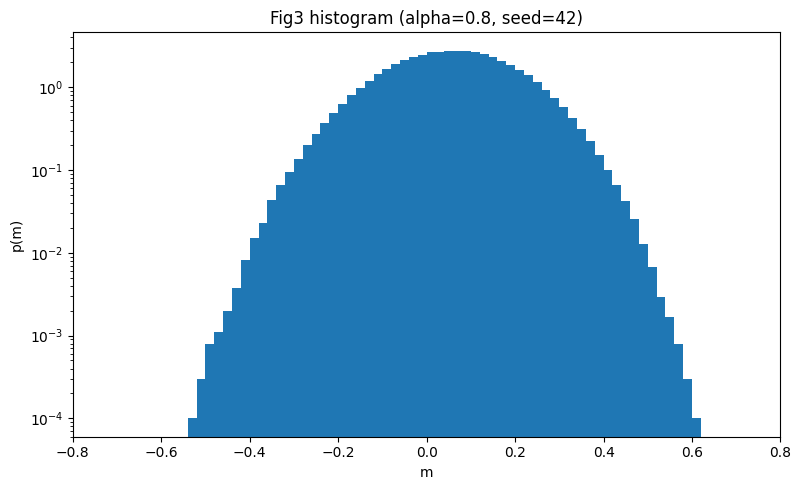

n=500000, min=-0.52603, max=0.607889, mean=0.0563285, std=0.139986

CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed42/tau100_h0.001_J0.1_α_inc1.0e-6/N100_alpha0.835_sample5K.csv


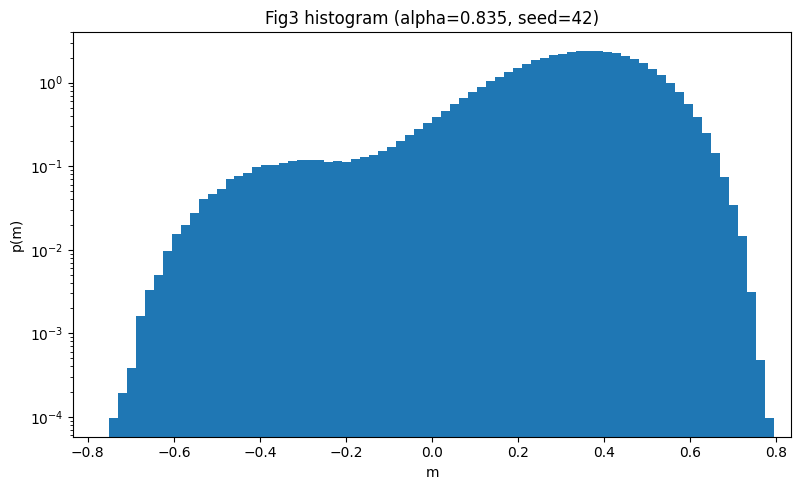

n=500000, min=-0.733356, max=0.775274, mean=0.299133, std=0.202152

CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed42/tau100_h0.001_J0.1_α_inc1.0e-6/N100_alpha0.9_sample5K.csv


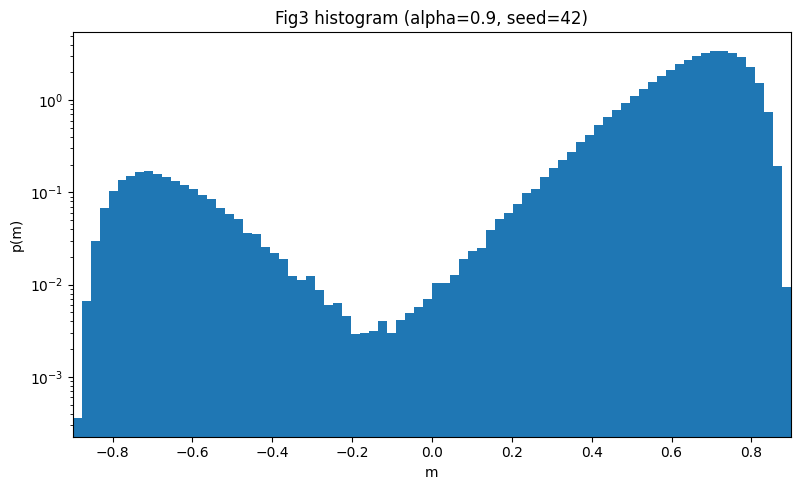

n=500000, min=-0.892518, max=0.892581, mean=0.589899, std=0.301776


In [7]:
seed = 42
tau = 100
h = 0.001
J = 0.1
alpha_inc = "1.0e-6"   # main.jl のディレクトリ名と一致させる
alphas = [0.8, 0.835, 0.9]

for a in alphas:
    csv_path = find_csv(seed=seed, end_alpha=a, tau=tau, h=h, J=J, alpha_inc=alpha_inc)
    print("\nCSV:", csv_path)

    M = load_M(csv_path)
    title = f"Fig3 histogram (alpha={a}, seed={seed})"
    show_fig3_hist(M, alpha=a, bins=80, density=True, title=title)



CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau1K_h0.001_J0.1_α_inc1.0e-6/N100_alpha0.8_sample5K.csv


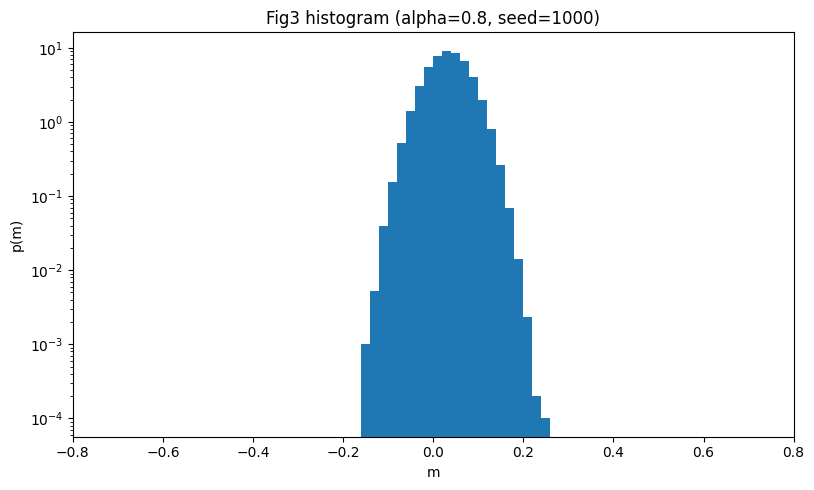

n=500000, min=-0.158781, max=0.246485, mean=0.034095, std=0.0430811

CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau1K_h0.001_J0.1_α_inc1.0e-6/N100_alpha0.85_sample5K.csv


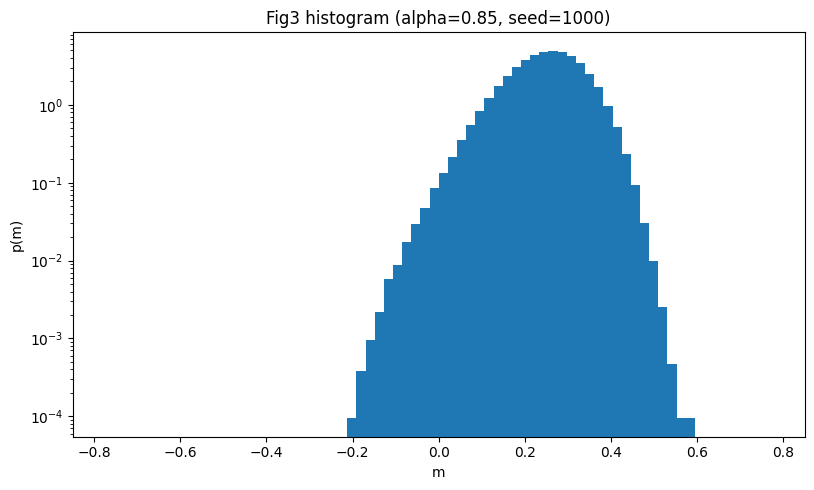

n=500000, min=-0.19677, max=0.582374, mean=0.249637, std=0.0818865

CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.001_J0.1_α_inc1.0e-7/N100_alpha0.9_sample5K.csv


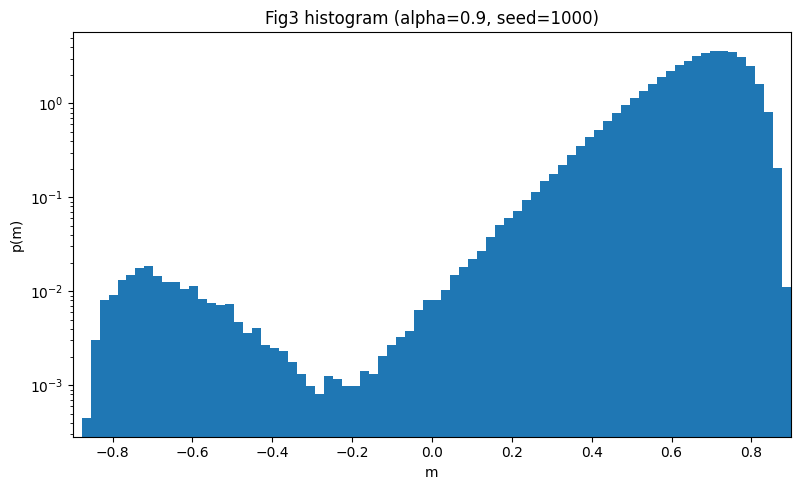

n=500000, min=-0.866066, max=0.895263, mean=0.646205, std=0.156032

CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau1K_h0.001_J0.1_α_inc1.0e-6/N100_alpha0.99_sample5K.csv


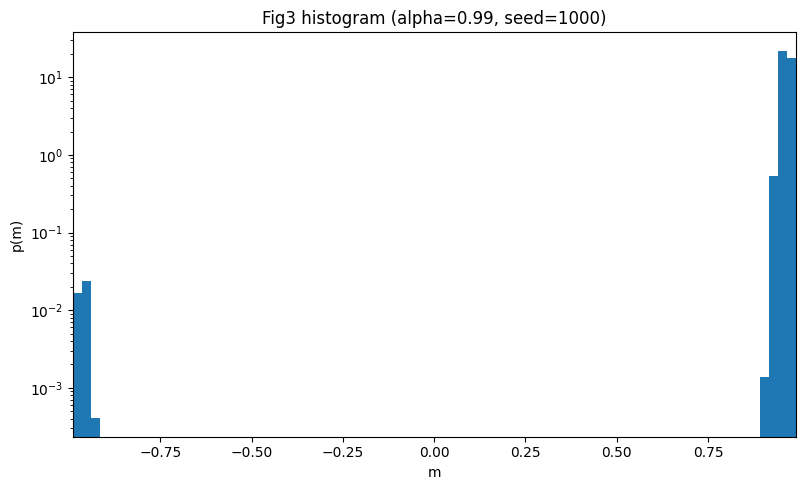

n=500000, min=-0.980229, max=0.987177, mean=0.961202, std=0.0614886


In [9]:
seed = 1000
tau = 1000
h = 0.001
J = 0.1
alpha_inc = "1.0e-6"   # main.jl のディレクトリ名と一致させる
alphas = [0.8, 0.85, 0.9, 0.99]

for a in alphas:
    csv_path = find_csv(seed=seed, end_alpha=a, tau=tau, h=h, J=J, alpha_inc=alpha_inc)
    print("\nCSV:", csv_path)

    M = load_M(csv_path)
    title = f"Fig3 histogram (alpha={a}, seed={seed})"
    show_fig3_hist(M, alpha=a, bins=80, density=True, title=title)



CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.001_J0.1_α_inc1.0e-7/N100_alpha0.9_sample5K.csv


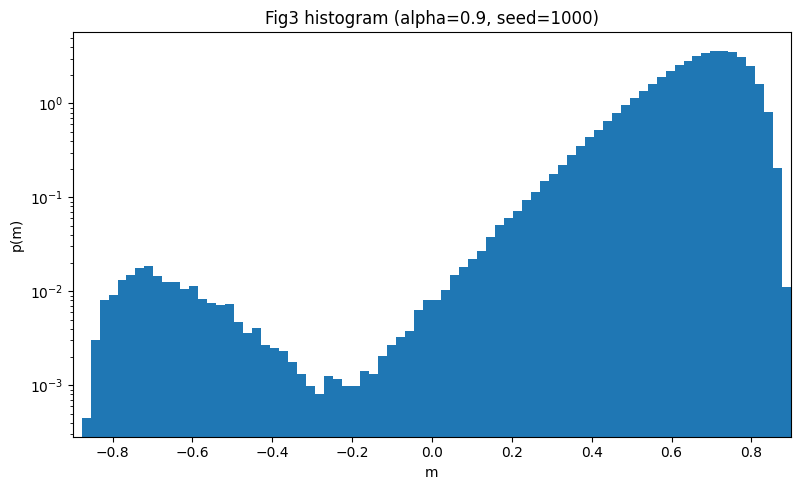

n=500000, min=-0.866066, max=0.895263, mean=0.646205, std=0.156032


In [31]:
seed = 1000
tau = 100
h = 0.001
J = 0.1
alpha_inc = "1.0e-7"   # main.jl のディレクトリ名と一致させる
alphas = [0.9]

for a in alphas:
    csv_path = find_csv(seed=seed, end_alpha=a, tau=tau, h=h, J=J, alpha_inc=alpha_inc)
    print("\nCSV:", csv_path)

    M = load_M(csv_path)
    title = f"Fig3 histogram (alpha={a}, seed={seed})"
    show_fig3_hist(M, alpha=a, bins=80, density=True, title=title)



CSV: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau1K_h0.001_J0.1_α_inc1.0e-7/N100_alpha0.9_sample5K.csv


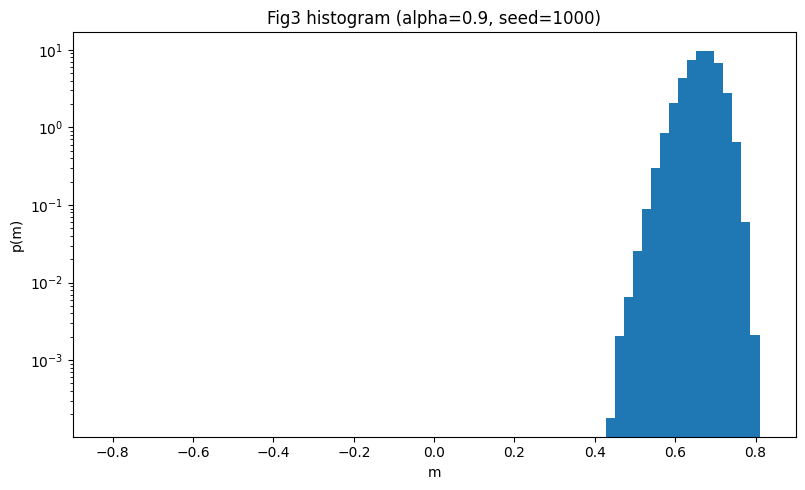

n=500000, min=0.449283, max=0.803679, mean=0.667062, std=0.0395365


In [30]:
seed = 1000
tau = 1000
h = 0.001
J = 0.1
alpha_inc = "1.0e-7"   # main.jl のディレクトリ名と一致させる
alphas = [0.9]

for a in alphas:
    csv_path = find_csv(seed=seed, end_alpha=a, tau=tau, h=h, J=J, alpha_inc=alpha_inc)
    print("\nCSV:", csv_path)

    M = load_M(csv_path)
    title = f"Fig3 histogram (alpha={a}, seed={seed})"
    show_fig3_hist(M, alpha=a, bins=80, density=True, title=title)
